In [3]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Import ML model
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics for regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load the CSV dataset
df = pd.read_csv("aqi_dataset.csv")

# Display the first 5 rows
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [5]:
# Display the number of rows and columns
print("Shape of dataset:", df.shape)

# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Shape of dataset: (3660, 13)
Columns in the dataset:
['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']


In [6]:
# Display the data type of each column
print("Data Types:")
print(df.dtypes)

Data Types:
Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object


In [7]:
# Display statistical summary of numerical columns
df.describe()

,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
mean,164.642077,126.380574,154.785956,52.960710,25.940328,5.023842,105.325929,15.061913,50.657104,7.788907
std,78.571659,71.016089,84.045548,27.361413,14.001531,2.851573,55.032175,14.590761,23.195880,4.223788
min,30.000000,5.100000,10.000000,5.100000,2.000000,0.100000,10.100000,-10.000000,10.000000,0.500000
25%,96.000000,63.700000,82.200000,29.175000,13.700000,2.590000,57.900000,2.175000,31.000000,4.100000
50%,165.000000,125.850000,152.550000,52.800000,26.200000,4.910000,105.750000,15.000000,51.000000,7.800000
75%,233.000000,187.000000,227.600000,76.700000,38.200000,7.560000,152.925000,27.525000,71.000000,11.500000
max,300.000000,250.000000,300.000000,100.000000,50.000000,9.990000,200.000000,40.000000,90.000000,15.000000


In [8]:
# Check the number of missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64


In [9]:
# Check the number of duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
# Check if missing values are present
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing numerical values with the median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with the mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Missing values after cleaning:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64


In [11]:
# Remove duplicate rows
df = df.drop_duplicates()

# Reset the index after removing duplicates
df = df.reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3660, 13)


In [12]:
# Convert the Date column from object/string to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check the updated data types
print(df.dtypes)

Date                datetime64[ns]
City                        object
Country                     object
AQI                          int64
PM2.5 (µg/m³)              float64
PM10 (µg/m³)               float64
NO2 (ppb)                  float64
SO2 (ppb)                  float64
CO (ppm)                   float64
O3 (ppb)                   float64
Temperature (°C)           float64
Humidity (%)                 int64
Wind Speed (m/s)           float64
dtype: object


In [13]:
# Select numerical columns for outlier handling
numeric_columns = df.select_dtypes(include=np.number).columns

# Use IQR method to identify and cap extreme values
for column in numeric_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Cap values instead of deleting rows
    df[column] = df[column].clip(lower=lower_limit, upper=upper_limit)

print("Outlier handling completed.")

Outlier handling completed.


In [14]:
# Separate the target variable from the input features

# AQI is our target variable
y = df["AQI"]

# Remove AQI from the dataset to create input features
X = df.drop("AQI", axis=1)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("AQI")

Features:
['Date', 'City', 'Country', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

Target:
AQI


In [15]:
# Identify categorical columns
categorical_features = ["City", "Country"]

# Identify numerical columns
numerical_features = [
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (ppb)",
    "SO2 (ppb)",
    "CO (ppm)",
    "O3 (ppb)",
    "Temperature (°C)",
    "Humidity (%)",
    "Wind Speed (m/s)",
    "Year",
    "Month",
    "Day"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numerical features
        ("num", StandardScaler(), numerical_features),
        
        # Encode categorical features
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Encoding and scaling setup completed.")

Encoding and scaling setup completed.


In [16]:
# Extract useful information from the Date column
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Display the new features
df[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2024-01-01,2024,1,1
1,2024-01-01,2024,1,1
2,2024-01-01,2024,1,1
3,2024-01-01,2024,1,1
4,2024-01-01,2024,1,1


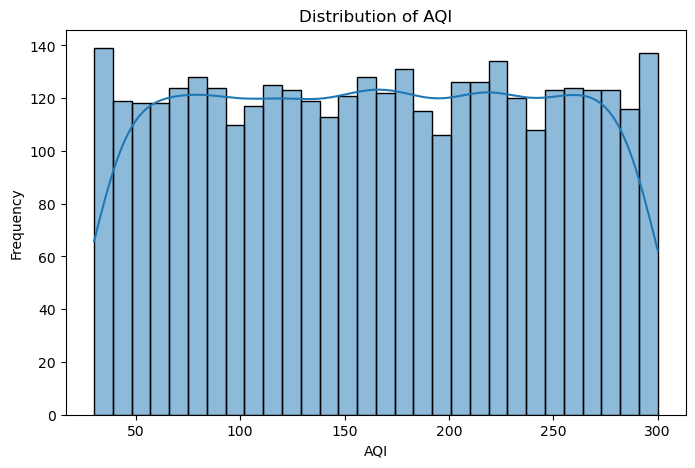

In [17]:
# Visualize the distribution of AQI values
plt.figure(figsize=(8, 5))

sns.histplot(df["AQI"], bins=30, kde=True)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

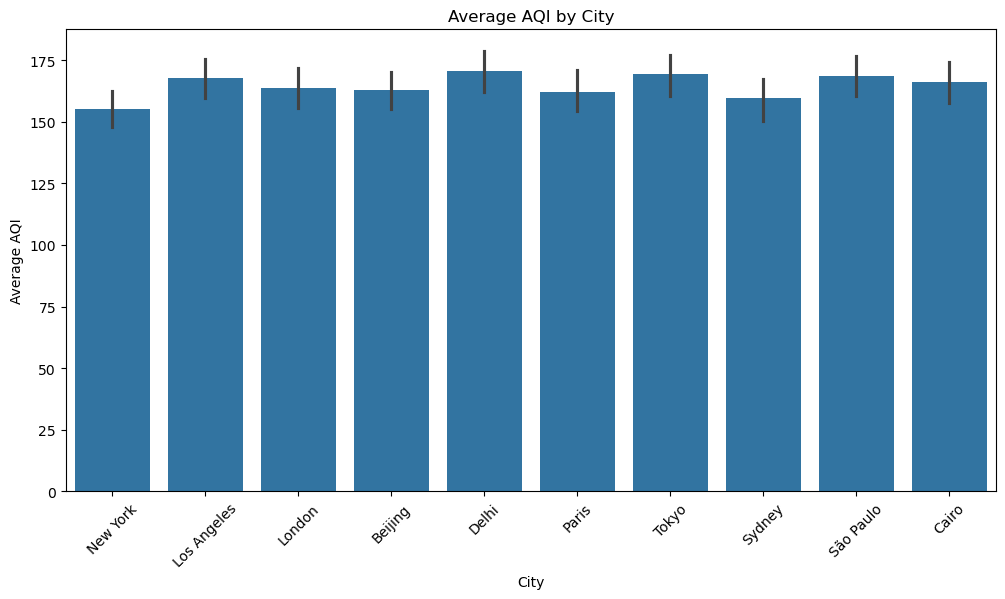

In [18]:
# Compare average AQI across different cities
plt.figure(figsize=(12, 6))

sns.barplot(data=df, x="City", y="AQI", estimator=np.mean)

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.show()

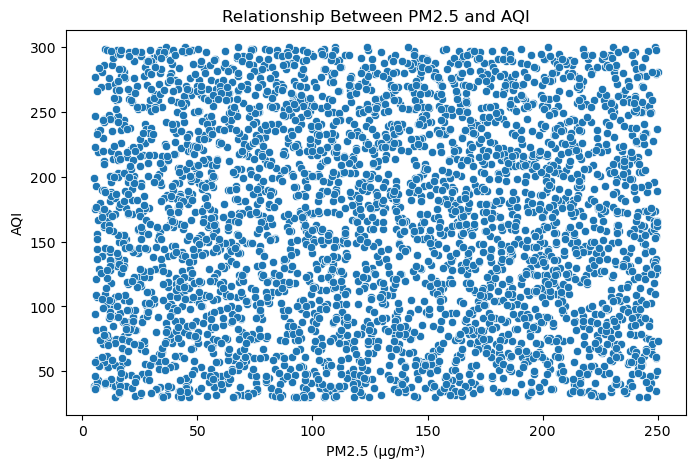

In [19]:
# Study the relationship between PM2.5 and AQI
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="PM2.5 (µg/m³)",
    y="AQI"
)

plt.title("Relationship Between PM2.5 and AQI")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("AQI")

plt.show()

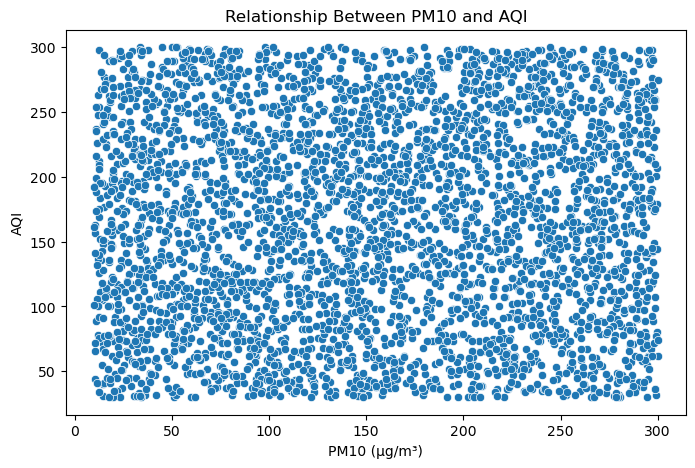

In [20]:
# Study the relationship between PM10 and AQI
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="PM10 (µg/m³)",
    y="AQI"
)

plt.title("Relationship Between PM10 and AQI")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("AQI")

plt.show()

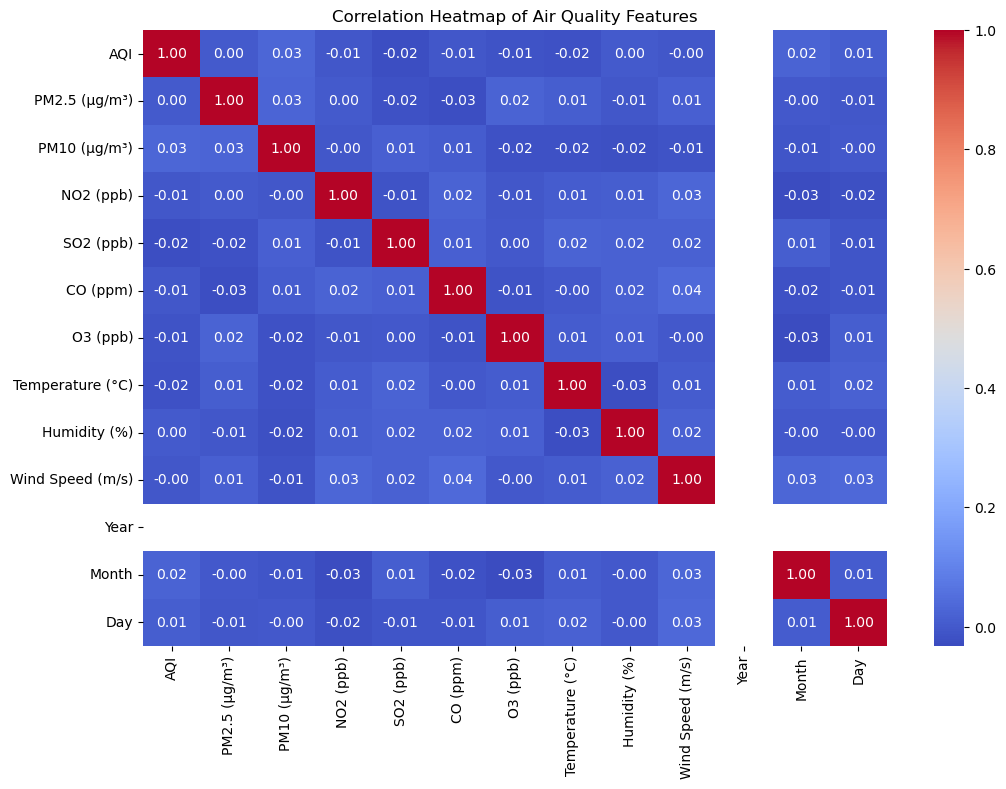

In [21]:
# Select numerical columns
correlation_data = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Air Quality Features")

plt.show()

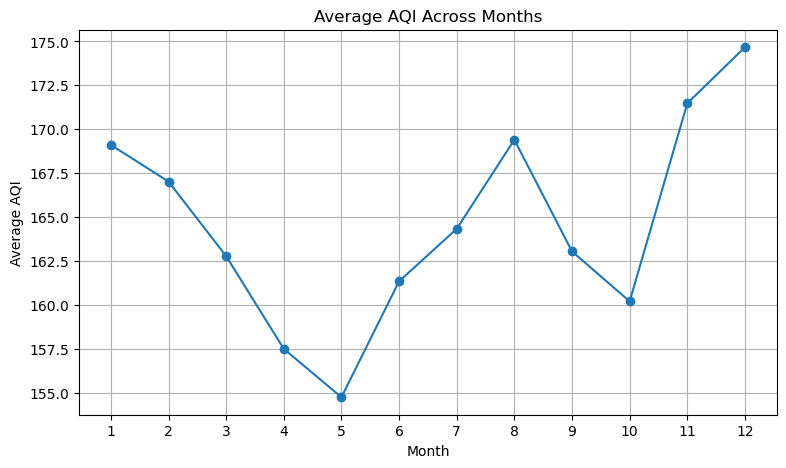

In [22]:
# Calculate average AQI for each month
monthly_aqi = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(9, 5))

plt.plot(monthly_aqi.index, monthly_aqi.values, marker="o")

plt.title("Average AQI Across Months")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

In [23]:
# Create additional useful features from the pollutant measurements

# Calculate an overall pollutant concentration
df["Total_Pollutants"] = (
    df["PM2.5 (µg/m³)"] +
    df["PM10 (µg/m³)"] +
    df["NO2 (ppb)"] +
    df["SO2 (ppb)"] +
    df["CO (ppm)"] +
    df["O3 (ppb)"]
)

# Create a PM ratio feature
df["PM2.5_PM10_Ratio"] = (
    df["PM2.5 (µg/m³)"] / (df["PM10 (µg/m³)"] + 1)
)

# Display the new features
df[["Total_Pollutants", "PM2.5_PM10_Ratio"]].head()

,Total_Pollutants,PM2.5_PM10_Ratio
0,515.60,0.652529
1,356.28,0.801670
2,401.17,4.762040
3,292.41,2.659341
4,436.52,0.334504


In [24]:
# Define the target
y = df["AQI"]

# Remove columns that should not be directly used
X = df.drop(["AQI", "Date"], axis=1)

# Display the final feature columns
print("Final features:")
print(X.columns.tolist())

Final features:
['City', 'Country', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Year', 'Month', 'Day', 'Total_Pollutants', 'PM2.5_PM10_Ratio']


In [25]:
# Split the dataset into training and testing sets
# 80% data is used for training
# 20% data is used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2928, 16)
Testing data shape: (732, 16)


In [26]:
# Identify categorical features
categorical_features = ["City", "Country"]

# Identify numerical features
numerical_features = [
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (ppb)",
    "SO2 (ppb)",
    "CO (ppm)",
    "O3 (ppb)",
    "Temperature (°C)",
    "Humidity (%)",
    "Wind Speed (m/s)",
    "Year",
    "Month",
    "Day",
    "Total_Pollutants",
    "PM2.5_PM10_Ratio"
]

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Apply preprocessing to training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to testing data
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Preprocessing completed.
Processed training data shape: (2928, 33)
Processed testing data shape: (732, 33)


In [27]:
# Create the Random Forest Regression model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train_processed, y_train)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


In [28]:
# Predict AQI values for the test dataset
y_pred = model.predict(X_test_processed)

# Display a few actual and predicted values
results = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": y_pred
})

results.head(10)

,Actual AQI,Predicted AQI
0,212,164.11
1,106,139.03
2,245,151.88
3,55,181.83
4,95,155.55
5,196,170.40
6,294,188.42
7,263,153.03
8,238,170.03
9,207,154.03


In [29]:
# Calculate regression evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

Model Evaluation
------------------------
MAE  : 70.16
MSE  : 6539.66
RMSE : 80.87
R²   : -0.03


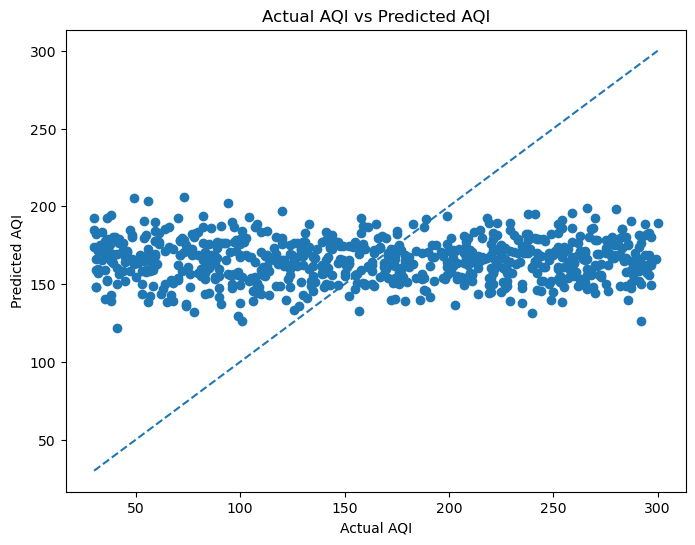

In [30]:
# Plot actual AQI values against predicted AQI values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Draw the ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual AQI vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.show()

In [31]:
# Create a new sample for AQI prediction

new_data = pd.DataFrame({
    "City": ["Delhi"],
    "Country": ["India"],
    "PM2.5 (µg/m³)": [120],
    "PM10 (µg/m³)": [200],
    "NO2 (ppb)": [45],
    "SO2 (ppb)": [20],
    "CO (ppm)": [1.5],
    "O3 (ppb)": [30],
    "Temperature (°C)": [25],
    "Humidity (%)": [55],
    "Wind Speed (m/s)": [3.5],
    "Year": [2026],
    "Month": [8],
    "Day": [28],
})

# Create the same engineered features used during training
new_data["Total_Pollutants"] = (
    new_data["PM2.5 (µg/m³)"] +
    new_data["PM10 (µg/m³)"] +
    new_data["NO2 (ppb)"] +
    new_data["SO2 (ppb)"] +
    new_data["CO (ppm)"] +
    new_data["O3 (ppb)"]
)

new_data["PM2.5_PM10_Ratio"] = (
    new_data["PM2.5 (µg/m³)"] /
    (new_data["PM10 (µg/m³)"] + 1)
)

# Apply the same preprocessing
new_data_processed = preprocessor.transform(new_data)

# Predict AQI
predicted_aqi = model.predict(new_data_processed)

print("Predicted AQI:", round(predicted_aqi[0], 2))

Predicted AQI: 176.7


In [32]:
# Display the final conclusion of the project

print("""
FINAL CONCLUSION
----------------

A Random Forest Regression model was developed to predict Air Quality Index (AQI)
using pollutant concentrations and environmental factors.

The model used:
- PM2.5
- PM10
- NO2
- SO2
- CO
- O3
- Temperature
- Humidity
- Wind Speed
- City
- Country
- Date-based features

The model was evaluated using MAE, MSE, RMSE and R² because AQI prediction
is a regression problem.

The trained model can be used to estimate AQI for new environmental conditions,
which can help in proactive air-quality monitoring and environmental management.
""")


FINAL CONCLUSION
----------------

A Random Forest Regression model was developed to predict Air Quality Index (AQI)
using pollutant concentrations and environmental factors.

The model used:
- PM2.5
- PM10
- NO2
- SO2
- CO
- O3
- Temperature
- Humidity
- Wind Speed
- City
- Country
- Date-based features

The model was evaluated using MAE, MSE, RMSE and R² because AQI prediction
is a regression problem.

The trained model can be used to estimate AQI for new environmental conditions,
which can help in proactive air-quality monitoring and environmental management.

